In [6]:
library(ggplot2)
library(patchwork)
source('tprf.r')

In [3]:
set.seed(42)

n_samples <- 150
n_features <- 20
n_relevant <- 5

# Factor F: Drives GDP and the first 5 indicators
F <- rnorm(n_samples, 0, 1)

# Factor G: Drives the NEXT 15 indicators, but DOES NOT drive GDP
G <- rnorm(n_samples, 0, 2)

# Target (GDP) depends ONLY on F
y <- 3 * F + rnorm(n_samples, 0, 0.5)

X <- matrix(0, n_samples, n_features)

# Relevant indicators: driven by F
for (i in 1:n_relevant) {
  loading <- runif(1, -2, 2)
  X[, i] <- loading * F + rnorm(n_samples, 0, 0.3)
}

# Irrelevant indicators: driven by G
for (i in (n_relevant + 1):n_features) {
  loading <- runif(1, 0.5, 1.5)
  X[, i] <- loading * G + rnorm(n_samples, 0, 0.3)
}

# --- Train / Test Split ---
train_size <- 100
X_train <- X[1:train_size, ]
X_test  <- X[(train_size + 1):n_samples, ]
y_train <- y[1:train_size]
y_test  <- y[(train_size + 1):n_samples]

# --- Test the TPRF Object ---
model <- TPRF$new()
model$fit(X_train, y_train)

learned_betas <- model$betas_

tprf_train <- model$transform(X_train)
tprf_test  <- model$transform(X_test)

# --- Evaluate Results ---
cat("--- Step 1 Betas (Loadings) ---\n")
cat(sprintf("Average absolute beta for RELEVANT features (0 to 4): %.4f\n",
            mean(abs(learned_betas[1:n_relevant]))))
cat(sprintf("Average absolute beta for IRRELEVANT features (5 to 19): %.4f\n",
            mean(abs(learned_betas[(n_relevant + 1):n_features]))))

cat("\n--- Factor Effectiveness ---\n")
corr_train <- cor(tprf_train, y_train)
corr_test  <- cor(tprf_test,  y_test)

cat(sprintf("Correlation(TPRF, GDP) on Training Set: %.4f\n", corr_train))
cat(sprintf("Correlation(TPRF, GDP) on Test Set:     %.4f\n", corr_test))

# Compare to a naive PCA approach (first principal component of X)
pca_fit <- prcomp(X_train, scale. = TRUE)
pca_train <- pca_fit$x[, 1]
corr_pca_train <- cor(pca_train, y_train)

# Project test set using the training center/scale/rotation
X_test_scaled <- sweep(sweep(X_test, 2, pca_fit$center, "-"),
                       2, pca_fit$scale, "/")
pca_test <- (X_test_scaled %*% pca_fit$rotation)[, 1]
corr_pca_test <- cor(pca_test, y_test)

cat(sprintf("\nCorrelation(PCA_1, GDP) on Training Set: %.4f\n", corr_pca_train))
cat(sprintf("Correlation(PCA_1, GDP) on Test Set:     %.4f\n", corr_pca_test))

--- Step 1 Betas (Loadings) ---
Average absolute beta for RELEVANT features (0 to 4): 0.7351
Average absolute beta for IRRELEVANT features (5 to 19): 0.0717

--- Factor Effectiveness ---
Correlation(TPRF, GDP) on Training Set: 0.9004
Correlation(TPRF, GDP) on Test Set:     0.8422

Correlation(PCA_1, GDP) on Training Set: -0.1000
Correlation(PCA_1, GDP) on Test Set:     -0.0586


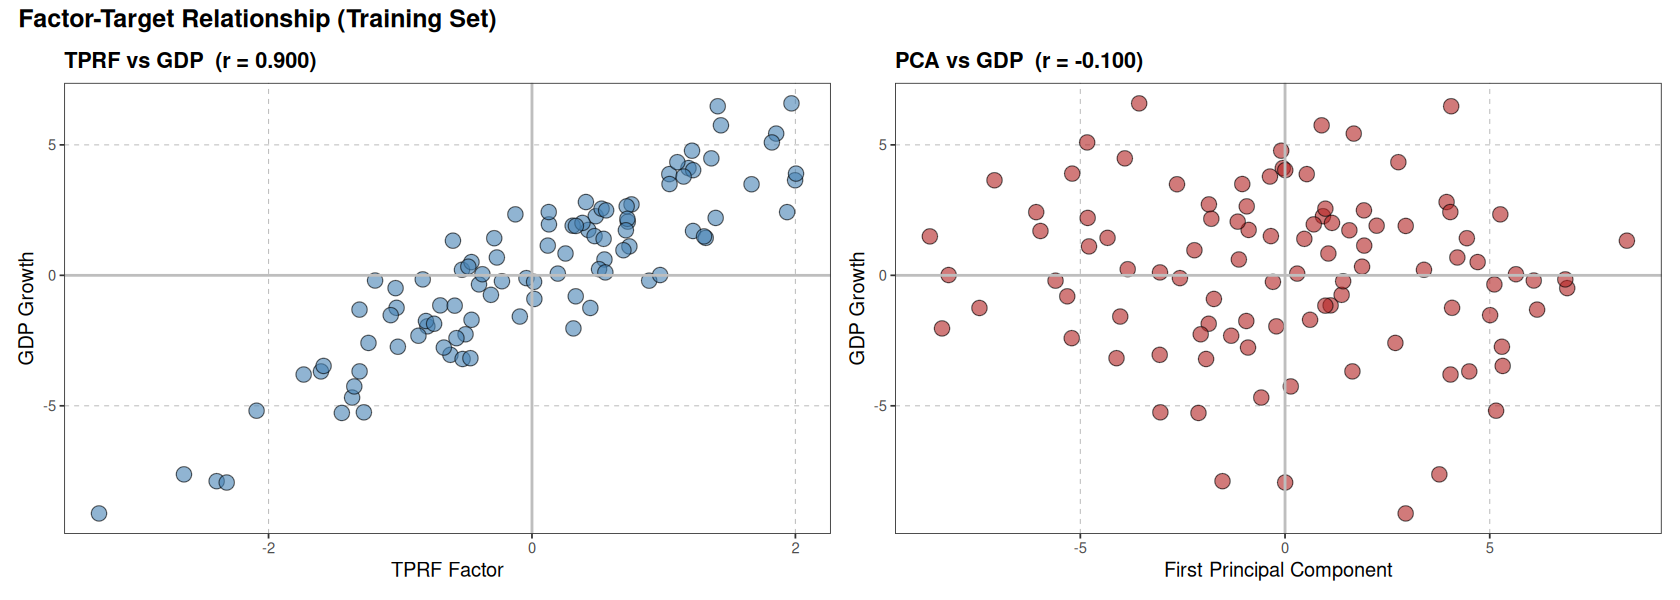

In [8]:
# Combine data into data frames for ggplot
df_tprf <- data.frame(x = tprf_train, y = y_train)
df_pca  <- data.frame(x = pca_train,  y = y_train)

# --- TPRF Scatter ---
p_tprf <- ggplot(df_tprf, aes(x = x, y = y)) +
  geom_point(alpha = 0.6, fill = "steelblue", color = "black", 
             shape = 21, size = 4, stroke = 0.5) +
  geom_hline(yintercept = 0, color = "grey", linewidth = 0.8) +
  geom_vline(xintercept = 0, color = "grey", linewidth = 0.8) +
  labs(
    x = "TPRF Factor",
    y = "GDP Growth",
    title = sprintf("TPRF vs GDP  (r = %.3f)", corr_train)
  ) +
  theme_bw() +
  theme(
    panel.grid.major = element_line(color = "grey", linetype = "dashed", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 13),
    axis.title = element_text(size = 12)
  )

# --- PCA Scatter ---
p_pca <- ggplot(df_pca, aes(x = x, y = y)) +
  geom_point(alpha = 0.6, fill = "firebrick", color = "black", 
             shape = 21, size = 4, stroke = 0.5) +
  geom_hline(yintercept = 0, color = "grey", linewidth = 0.8) +
  geom_vline(xintercept = 0, color = "grey", linewidth = 0.8) +
  labs(
    x = "First Principal Component",
    y = "GDP Growth",
    title = sprintf("PCA vs GDP  (r = %.3f)", corr_pca_train)
  ) +
  theme_bw() +
  theme(
    panel.grid.major = element_line(color = "grey", linetype = "dashed", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 13),
    axis.title = element_text(size = 12)
  )

# --- Combine and Display ---
combined_plot <- (p_tprf | p_pca) + 
  plot_annotation(
    title = "Factor-Target Relationship (Training Set)",
    theme = theme(plot.title = element_text(size = 15, face = "bold"))
  )

options(repr.plot.width = 14, repr.plot.height = 5)
print(combined_plot)